![image.png](https://i.imgur.com/a3uAqnb.png)

# Reasoning with Prompting and Search

- **Dataset**: [GSM8K](https://huggingface.co/datasets/openai/gsm8k) test problems from Hugging Face, and the Game of 24 puzzle file from the [Tree of Thoughts](https://github.com/princeton-nlp/tree-of-thought-llm) repository
- **Task**: grade-school math word problems graded exactly, and the Game of 24 arithmetic puzzle
- **Model**: [Qwen/Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct), used as it is (no training), with [Math-Verify](https://github.com/huggingface/Math-Verify) as the grader
- **Runtime**: Colab T4 GPU, about 20 minutes of generation

In this lab, we will:

- build an evaluation harness for a small open model: batched generation, an exact symbolic grader and token accounting
- implement direct answering, chain-of-thought and self-consistency voting as reusable functions with one interface
- implement a Tree-of-Thought breadth-first search on Game of 24 with the original propose and value prompts
- end with one table of accuracy against generated tokens for every method

## What are prompting and search at inference time?

A language model answers a question $q$ by sampling a reasoning path $r$ and an answer $a$ from $\mathbb{P}(r, a \mid q)$. Greedy decoding returns the single most likely pair. Chain-of-thought prompting makes the path explicit, so the model spends tokens on intermediate steps before the answer. Self-consistency samples $N$ paths and keeps the most frequent answer, which estimates the marginal over paths instead of the most likely path:

$$\mathbb{P}(a \mid q) = \sum_{r} \mathbb{P}(r, a \mid q) \approx \frac{\#\{i : a_i = a\}}{N}, \qquad \hat{a} = \arg\max_a \mathbb{P}(a \mid q)$$

Where:
- $q$ is the question and $r$ one reasoning path (a chain of thought)
- $a_i$ is the final answer extracted from the $i$-th of $N$ sampled paths
- $\hat{a}$ is the answer returned by the vote (the most frequent one)

Tree-of-Thought replaces the single path with a search. A state is a partial solution, the model *proposes* next steps from each state, the model *values* each new state (sure, likely or impossible), and a breadth-first search keeps the $b$ best states at each depth. 

Papers: [Wei et al., 2022. Chain-of-Thought Prompting Elicits Reasoning in Large Language Models](https://arxiv.org/abs/2201.11903), [Wang et al., 2022. Self-Consistency Improves Chain of Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171), [Yao et al., 2023. Tree of Thoughts: Deliberate Problem Solving with Large Language Models](https://arxiv.org/abs/2305.10601)

## Setup

In Google Colab, select **Runtime > Change runtime type > T4 GPU**, then run the cells from top to bottom.

In [1]:
%pip install -q "math-verify[antlr4_13_2]"
%pip install -q --no-deps tree-of-thoughts-llm   # only for its prompts and the Game of 24 puzzle file

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.1 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.13.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 4.6 MB/s eta 0:00:00


In [2]:
import os
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy
from datasets import load_dataset
from math_verify import parse, verify

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

In [3]:
SEED = 42
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"   # 1.5B parameters, Apache-2.0, about 3 GB in half precision
N_TEST = 32                 # GSM8K test problems (the split has 1,319)
N_PUZZLES = 10              # Game of 24 puzzles from the paper's test range (ranks 901 to 1000)
N_SAMPLES = 8               # samples per problem for self-consistency
TEMPERATURE = 0.7           # sampling temperature for self-consistency and the search
BREADTH = 5                 # states kept per depth in the Tree-of-Thought search (b = 5 in the paper)
BATCH_SIZE = 16             # prompts per generate call
MAX_NEW_TOKENS = 400        # budget for one chain of thought on GSM8K
MAX_DIRECT_TOKENS = 12      # budget for a direct answer (a number inside a box)
STEP_TOKENS = 120           # budget for one Game of 24 chain or one propose call
VALUE_TOKENS = 60           # budget for one value judgement

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
else:
    print("No GPU found, so generation will be slow. In Colab: Runtime > Change runtime type > T4 GPU.")

# Inference only, so no gradient scaler: float16 weights on a T4, which has no bfloat16 units,
# bfloat16 on an A100 or newer, float32 on the CPU.
if DEVICE == "cuda":
    DTYPE = torch.bfloat16 if torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
else:
    DTYPE = torch.float32

PyTorch 2.11.0+cu130 | device: cuda
GPU: Tesla T4 (15.6 GB)


## 1. Dataset

- **Source**: [GSM8K](https://huggingface.co/datasets/openai/gsm8k) on Hugging Face ([Cobbe et al., 2021](https://arxiv.org/abs/2110.14168)), configuration `main`
- **Content**: 8,500 grade-school math word problems, 7,473 train and 1,319 test, each with a worked solution whose last line is `#### <number>`
- **Licence**: MIT
- **What we use**: a seeded subset of the test split, with the gold number taken from after `####` and its thousands separators removed

The second task set is the Game of 24 puzzle file that ships with the Tree of Thoughts package (MIT licence): 1,362 puzzles sorted from easy to hard by human solving time. The paper evaluates on ranks 901 to 1000, so we take every tenth puzzle of that range.

In [4]:
gsm8k = load_dataset("openai/gsm8k", "main", split="test").shuffle(seed=SEED).select(range(N_TEST))
problems = [(row["question"], row["answer"].split("####")[-1].strip().replace(",", "")) for row in gsm8k]
print(gsm8k)
print(problems[0][0], "\n-> gold:", problems[0][1])

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.31MB            

main/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

main/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  419kB            

main/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer'],
    num_rows: 32
})
Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now. 
-> gold: 109


The puzzle file and the prompts come from the Tree of Thoughts package. A puzzle is four numbers, and a solution uses each once with `+ - * /` to reach 24.

In [5]:
import tot
from tot.prompts.game24 import cot_prompt, propose_prompt, value_prompt

puzzle_file = os.path.join(os.path.dirname(tot.__file__), "data", "24", "24.csv")
puzzles = list(pd.read_csv(puzzle_file)["Puzzles"])[900:1000:100 // N_PUZZLES]
print("puzzles:", puzzles)
print(propose_prompt.format(input="4 6 12"))

puzzles: ['4 5 6 10', '4 5 7 9', '1 5 9 13', '2 4 6 7', '3 4 9 13', '1 2 2 9', '2 6 8 13', '4 4 8 12', '3 4 6 6', '3 4 8 12']
Input: 2 8 8 14
Possible next steps:
2 + 8 = 10 (left: 8 10 14)
8 / 2 = 4 (left: 4 8 14)
14 + 2 = 16 (left: 8 8 16)
2 * 8 = 16 (left: 8 14 16)
8 - 2 = 6 (left: 6 8 14)
14 - 8 = 6 (left: 2 6 8)
14 /  2 = 7 (left: 7 8 8)
14 - 2 = 12 (left: 8 8 12)
Input: 4 6 12
Possible next steps:



### The grader

Math-Verify extracts the final answer from free text (a boxed expression first, then the last number or expression), parses both sides to SymPy and compares them symbolically. The gold answer goes first, as the README insists. A parse failure returns an empty list, so an unparseable completion counts as wrong, not as a crash.

In [6]:
def is_correct(completion, gold):
    """True when Math-Verify judges the completion's final answer equal to the gold number."""
    return verify(parse(gold), parse(completion))


for text in ["The answer is \\boxed{18}.", "So she makes 18 dollars a day.", "\\boxed{1,800}", "I am not sure."]:
    print(f"{is_correct(text, '18')!s:5} <- {text!r}")

True  <- 'The answer is \\boxed{18}.'
True  <- 'So she makes 18 dollars a day.'
False <- '\\boxed{1,800}'
False <- 'I am not sure.'


## 2. Method

The harness has three parts: a chat formatter, a batched `generate` that returns completions and the number of tokens each one cost, and the grader above. Every method is then a *solver*: a function that takes the list of problems and returns one chosen completion per problem plus the tokens it spent. Prompts are duplicated `n` times and generated in one batch, as search-and-learn does, so sampling $N$ paths costs one call.

In [7]:
tok = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side="left")   # left padding: new tokens start aligned
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE).to(DEVICE).eval()
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B, dtype {DTYPE}")


def chat(prompt, system=None):
    """Format one user turn (with an optional system prompt) with the model's chat template."""
    messages = ([{"role": "system", "content": system}] if system else []) + [{"role": "user", "content": prompt}]
    return tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


@torch.no_grad()
def generate(texts, n=1, max_new_tokens=MAX_NEW_TOKENS, temperature=0.0):
    """For each text, n completions and the number of tokens generated for each.
    Returns (completions, token_counts), both lists of lists with shape (len(texts), n)."""
    sampling = dict(do_sample=True, temperature=temperature, top_p=1.0) if temperature > 0 else dict(do_sample=False)
    texts = [t for t in texts for _ in range(n)]              # duplicate each prompt n times
    outputs, counts = [], []
    for start in range(0, len(texts), BATCH_SIZE):
        enc = tok(texts[start:start + BATCH_SIZE], return_tensors="pt", padding=True, add_special_tokens=False).to(DEVICE)
        gen = model.generate(**enc, max_new_tokens=max_new_tokens, pad_token_id=tok.pad_token_id, **sampling)
        new = gen[:, enc.input_ids.shape[1]:]                   # (B, new_tokens): drop the prompt
        outputs += tok.batch_decode(new, skip_special_tokens=True)
        counts += (new != tok.pad_token_id).sum(dim=1).tolist()
    regroup = lambda xs: [xs[i:i + n] for i in range(0, len(xs), n)]
    return regroup(outputs), regroup(counts)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Parameters: 1.54B, dtype torch.float16


### Direct answering and chain-of-thought

Both solvers use greedy decoding. The direct solver asks for the number only and *prefills* the assistant turn with `\boxed{`, so the model has to continue inside the box and cannot start reasoning. The chain-of-thought solver uses the Qwen2.5-Math system prompt and lets the model write its steps before the box. `evaluate_solver` runs any solver on every problem and records accuracy and tokens per problem.

In [8]:
DIRECT = "Answer with the final number only, written as \\boxed{number}. Do not show any working."
COT = "Please reason step by step, and put your final answer within \\boxed{}."   # the Qwen2.5-Math system prompt


def solve_direct(questions):
    """Greedy, no working: the assistant turn starts with an open box. Returns (answers, tokens)."""
    prefill = "\\boxed{"
    texts, counts = generate([chat(q, DIRECT) + prefill for q in questions], max_new_tokens=MAX_DIRECT_TOKENS)
    return [prefill + t[0] for t in texts], [c[0] for c in counts]


def solve_cot(questions):
    """Greedy chain of thought ending in a boxed answer. Returns (answers, tokens)."""
    texts, counts = generate([chat(q, COT) for q in questions])
    return [t[0] for t in texts], [c[0] for c in counts]


def evaluate_solver(name, solver, problems):
    """Run a solver on every problem. Returns a results row and the chosen completions."""
    start = time.time()
    answers, tokens = solver([q for q, _ in problems])
    accuracy = np.mean([is_correct(a, gold) for a, (_, gold) in zip(answers, problems)])
    row = {"method": name, "accuracy": float(accuracy), "tokens per problem": float(np.mean(tokens))}
    print(f"{name:28s} accuracy {accuracy:.3f} | {np.mean(tokens):6.1f} tokens/problem | {time.time() - start:.0f}s")
    return row, answers

### Self-consistency

The vote groups completions whose answers Math-Verify judges equal, so `0.5` and `\frac{1}{2}` fall in one group, and returns the first completion of the largest group. Completions with no extractable answer get no vote. The solver samples `N_SAMPLES` paths once and keeps them, so votes over the first $n$ samples reuse the same pool.

In [9]:
def answer_groups(completions, weights=None):
    """Group completions whose answers Math-Verify judges equal.
    Returns [[total weight, index of the first member, parsed answer], ...]."""
    weights = weights or [1.0] * len(completions)
    groups = []
    for i, (completion, w) in enumerate(zip(completions, weights)):
        answer = parse(completion)
        if not answer:                                   # nothing extractable: no vote
            continue
        for group in groups:
            if verify(group[2], answer):
                group[0] += w
                break
        else:
            groups.append([w, i, answer])
    return groups


def majority_vote(completions):
    """Self-consistency: the completion whose answer is shared by most samples (the first one on ties)."""
    groups = answer_groups(completions)
    return completions[max(groups, key=lambda g: g[0])[1]] if groups else ""


def sample_paths(questions, n=N_SAMPLES):
    """Sample n chains of thought per question at TEMPERATURE. Returns (samples, tokens), shape (len, n)."""
    return generate([chat(q, COT) for q in questions], n=n, temperature=TEMPERATURE)


def make_vote_solver(samples, counts, n):
    """A solver that votes over the first n of the stored samples (no new generation)."""
    def solver(questions):
        return [majority_vote(s[:n]) for s in samples], [sum(c[:n]) for c in counts]
    return solver

### Game of 24: program checks

A 1.5B model makes arithmetic slips that the paper's GPT-4 did not, so a program checks each proposed step (the two numbers must be available and the result must be right) and rewrites it with the correct numbers left. `expression` assembles one arithmetic expression from a chain of checked steps, and `solved` accepts a trajectory when the repository's check passes on an `Answer:` line or when the assembled expression equals 24 and uses each puzzle number once.

In [10]:
STEP = re.compile(r"\s*(\d+(?:\.\d+)?)\s*([-+*/])\s*(\d+(?:\.\d+)?)\s*=\s*(\d+(?:\.\d+)?)")
fmt = lambda x: f"{x:g}"


def numbers_left(trajectory):
    """Numbers still available after the last step: '... (left: 4 6 12)' -> '4 6 12'."""
    return trajectory.strip().split("\n")[-1].split("left: ")[-1].split(")")[0]


def checked_step(available, line):
    """If the line combines two available numbers correctly, return it rewritten with the correct numbers left, else None."""
    match = STEP.match(line)
    if not match:
        return None
    a, op, b, c = float(match[1]), match[2], float(match[3]), float(match[4])
    rest = sorted(map(float, available.split()))
    for x in (a, b):
        if x not in rest:
            return None
        rest.remove(x)
    if op == "/" and b == 0:
        return None
    value = {"+": a + b, "-": a - b, "*": a * b, "/": a / b if b else None}[op]
    if abs(value - c) > 0.01:
        return None
    return f"{fmt(a)} {op} {fmt(b)} = {fmt(value)} (left: {' '.join(map(fmt, sorted(rest + [value])))})"


def expression(puzzle, trajectory):
    """Assemble one expression from a chain of checked steps by substituting each result with what produced it."""
    pool = [(float(x), x) for x in puzzle.split()]
    for line in trajectory.strip().split("\n"):
        match = STEP.match(line)
        if not match:
            return None
        a, op, b, c = float(match[1]), match[2], float(match[3]), float(match[4])
        try:
            ea = pool.pop(next(i for i, (v, _) in enumerate(pool) if v == a))
            eb = pool.pop(next(i for i, (v, _) in enumerate(pool) if v == b))
        except StopIteration:
            return None
        pool.append((c, f"({ea[1]} {op} {eb[1]})"))
    return pool[0][1] if len(pool) == 1 else None


def solved(puzzle, text):
    """Correct if the repository's check passes on an 'Answer:' line, or if the steps assemble to 24."""
    lines = [l for l in text.strip().split("\n") if l.strip()]
    answer_lines = [l for l in lines if l.lower().startswith("answer")]
    steps = [l for l in lines if STEP.match(l) and not l.lower().startswith("answer")]
    candidates = [l.lower().replace("answer: ", "").split("=")[0] for l in answer_lines] + [expression(puzzle, "\n".join(steps))]
    for expr in candidates:
        if expr and sorted(re.findall(r"\d+", expr)) == sorted(puzzle.split()):
            try:
                if sympy.simplify(expr) == 24:
                    return True
            except Exception:
                pass
    return False


print(checked_step("4 6 12", "12 / 4 = 3"), "|", checked_step("4 6 12", "12 / 4 = 4"))
print(expression("4 6 12 1", "12 / 4 = 3 (left: 1 3 6)\n3 * 6 = 18 (left: 1 18)\n18 + 1 = 19 (left: 19)"))

12 / 4 = 3 (left: 3 6) | None
(((12 / 4) * 6) + 1)


### Tree-of-Thought: propose, value, breadth-first search

`propose` asks the model for next steps from each trajectory and keeps those that pass the program check. `value` asks the model whether the numbers left can still reach 24 and maps its label to the repository's weights (sure 20, likely 1, impossible 0.001). A complete chain is valued by the program instead. `tree_of_thought` runs the three depths and keeps the `BREADTH` best states at each one. The model's completions are cut where it starts writing a new few-shot example of its own.

In [11]:
VALUE_MAP = {"impossible": 0.001, "likely": 1.0, "sure": 20.0}   # the repository's value map


def first_block(text):
    """Cut the completion where the model starts writing a new few-shot 'Input:' example of its own."""
    return text.split("\nInput")[0]


def propose(puzzle, trajectories, spent):
    """ToT propose step: one call per trajectory, one candidate per returned line that passes the program check."""
    texts, counts = generate([propose_prompt.format(input=numbers_left(y or puzzle)) for y in trajectories],
                             max_new_tokens=STEP_TOKENS, temperature=TEMPERATURE)
    spent[0] += sum(c[0] for c in counts)
    candidates = []
    for y, text in zip(trajectories, texts):
        for line in first_block(text[0]).split("\n"):
            step = checked_step(numbers_left(y or puzzle), line)
            if step and y + step + "\n" not in candidates:
                candidates.append(y + step + "\n")
    return candidates


def value(puzzle, trajectories, spent):
    """ToT value step: the model rates the numbers left as sure, likely or impossible. Complete chains go to the program."""
    scores = [None] * len(trajectories)
    todo = [i for i, y in enumerate(trajectories) if len(numbers_left(y).split()) > 1]
    if todo:
        texts, counts = generate([value_prompt.format(input=numbers_left(trajectories[i])) for i in todo],
                                 max_new_tokens=VALUE_TOKENS)
        spent[0] += sum(c[0] for c in counts)
        for i, text in zip(todo, texts):
            labels = re.findall(r"sure|likely|impossible", first_block(text[0]).lower())
            scores[i] = VALUE_MAP[labels[-1]] if labels else 0.0
    for i, y in enumerate(trajectories):
        if scores[i] is None:
            scores[i] = 20.0 if solved(puzzle, y) else 0.0
    return scores


def tree_of_thought(puzzle):
    """Breadth-first search as in the repository: propose, value, keep the best BREADTH, for the three steps.
    Returns (trajectory, tokens spent)."""
    spent = [0]
    trajectories = [""]
    for _ in range(3):
        candidates = propose(puzzle, trajectories, spent)
        if not candidates:
            return "", spent[0]
        scores = value(puzzle, candidates, spent)
        trajectories = [y for _, y in sorted(zip(scores, candidates), key=lambda pair: -pair[0])][:BREADTH]
    return next((y for y in trajectories if solved(puzzle, y)), trajectories[0]), spent[0]

## 3. Run

Each solver prints its accuracy, its tokens per problem and the elapsed time. Expected time: about 1 minute for the two greedy solvers, about 6 minutes for the sampling pool and about 8 minutes for Game of 24, on a T4.

In [12]:
rows = []
row, direct_answers = evaluate_solver("Direct answer", solve_direct, problems)
rows.append(row)
row, cot_answers = evaluate_solver("Chain-of-thought", solve_cot, problems)
rows.append(row)
print("\nExample chain of thought:\n", cot_answers[0])

Direct answer                accuracy 0.062 |    4.1 tokens/problem | 3s
Chain-of-thought             accuracy 0.656 |  291.2 tokens/problem | 34s

Example chain of thought:
 To determine Allen's age 10 years from now, we need to follow these steps:

1. **Define Variables:**
   Let \( D \) represent Darrell's current age.
   Let \( A \) represent Allen's current age.

2. **Set Up Ratios:**
   According to the problem, the ratio of Darrell's age to Allen's age is 7:11:
   \[
   \frac{D}{A} = \frac{7}{11}
   \]

3. **Express One Variable in Terms of the Other:**
   From the ratio, we can express Darrell's age in terms of Allen's age:
   \[
   D = \frac{7}{11}A
   \]

4. **Use Total Age Equation:**
   The sum of their ages is given as 162:
   \[
   D + A = 162
   \]
   Substitute \( D \) from the previous equation into this total age equation:
   \[
   \frac{7}{11}A + A = 162
   \]

5. **Combine Like Terms:**
   To combine the terms on the left side, find a common denominator (which is 11

In [13]:
start = time.time()
samples, sample_counts = sample_paths([q for q, _ in problems])
print(f"sampled {N_SAMPLES} paths for {len(problems)} problems in {time.time() - start:.0f}s")

for n in [1, 2, 4, 8]:
    if n <= N_SAMPLES:
        row, _ = evaluate_solver(f"Self-consistency, N={n}", make_vote_solver(samples, sample_counts, n), problems)
        rows.append(row)

coverage = np.mean([any(is_correct(c, gold) for c in s) for s, (_, gold) in zip(samples, problems)])
rows.append({"method": f"Coverage, N={N_SAMPLES} (any sample correct)", "accuracy": float(coverage),
             "tokens per problem": float(np.mean([sum(c) for c in sample_counts]))})
print(f"coverage at N={N_SAMPLES}: {coverage:.3f}")

sampled 8 paths for 32 problems in 273s
Self-consistency, N=1        accuracy 0.438 |  266.4 tokens/problem | 0s
Self-consistency, N=2        accuracy 0.438 |  551.3 tokens/problem | 0s
Self-consistency, N=4        accuracy 0.594 | 1089.0 tokens/problem | 0s
Self-consistency, N=8        accuracy 0.625 | 2148.3 tokens/problem | 1s
coverage at N=8: 0.719


In [14]:
start = time.time()
cot24_texts, cot24_counts = generate([cot_prompt.format(input=p) for p in puzzles], max_new_tokens=STEP_TOKENS)
cot24_samples, cot24_sample_counts = generate([cot_prompt.format(input=p) for p in puzzles], n=BREADTH,
                                              max_new_tokens=STEP_TOKENS, temperature=TEMPERATURE)
print(f"chain-of-thought on {len(puzzles)} puzzles: {time.time() - start:.0f}s")

tot_results, tot_tokens = [], []
for i, p in enumerate(puzzles, 1):
    trajectory, spent = tree_of_thought(p)
    tot_results.append(trajectory)
    tot_tokens.append(spent)
    print(f"puzzle {i}/{len(puzzles)} {p:12s} {'solved' if solved(p, trajectory) else 'not solved':10s} "
          f"{spent:5d} tokens | {time.time() - start:.0f}s elapsed")

chain-of-thought on 10 puzzles: 33s
puzzle 1/10 4 5 6 10     not solved  3000 tokens | 58s elapsed
puzzle 2/10 4 5 7 9      not solved  3180 tokens | 83s elapsed
puzzle 3/10 1 5 9 13     not solved  3480 tokens | 108s elapsed
puzzle 4/10 2 4 6 7      not solved  2460 tokens | 133s elapsed
puzzle 5/10 3 4 9 13     not solved  3060 tokens | 159s elapsed
puzzle 6/10 1 2 2 9      not solved  2400 tokens | 180s elapsed
puzzle 7/10 2 6 8 13     solved      2640 tokens | 202s elapsed
puzzle 8/10 4 4 8 12     not solved  3000 tokens | 227s elapsed
puzzle 9/10 3 4 6 6      not solved  2460 tokens | 252s elapsed
puzzle 10/10 3 4 8 12     not solved  3240 tokens | 296s elapsed


## 4. Results

The GSM8K table lists every method with its accuracy and its cost. Coverage is the oracle selector: the accuracy a perfect verifier would reach on the same samples.

In [15]:
results = pd.DataFrame(rows).set_index("method").round(3)
results

,accuracy,tokens per problem
method,,
Direct answer,0.062,4.062
Chain-of-thought,0.656,291.250
"Self-consistency, N=1",0.438,266.406
"Self-consistency, N=2",0.438,551.312
"Self-consistency, N=4",0.594,1089.031
"Self-consistency, N=8",0.625,2148.312
"Coverage, N=8 (any sample correct)",0.719,2148.312


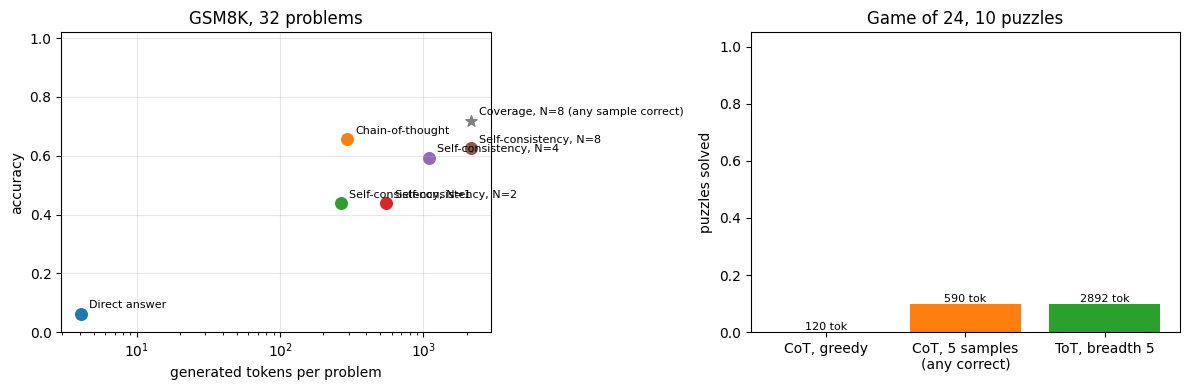

In [16]:
fig, (ax_gsm, ax_24) = plt.subplots(1, 2, figsize=(12, 4))
for method, r in results.iterrows():
    is_oracle = method.startswith("Coverage")
    ax_gsm.scatter(r["tokens per problem"], r["accuracy"], s=70, marker="*" if is_oracle else "o",
                   color="grey" if is_oracle else None)
    ax_gsm.annotate(method, (r["tokens per problem"], r["accuracy"]), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax_gsm.set(xlabel="generated tokens per problem", ylabel="accuracy", title=f"GSM8K, {len(problems)} problems", xscale="log")
ax_gsm.set_ylim(0, 1.02)
ax_gsm.grid(alpha=0.3)

solved_24 = [sum(solved(p, first_block(t[0])) for p, t in zip(puzzles, cot24_texts)),
             sum(any(solved(p, first_block(t)) for t in s) for p, s in zip(puzzles, cot24_samples)),
             sum(solved(p, y) for p, y in zip(puzzles, tot_results))]
tokens_24 = [np.mean([c[0] for c in cot24_counts]), np.mean([sum(c) for c in cot24_sample_counts]), np.mean(tot_tokens)]
names_24 = ["CoT, greedy", f"CoT, {BREADTH} samples\n(any correct)", f"ToT, breadth {BREADTH}"]
bars = ax_24.bar(names_24, [s / len(puzzles) for s in solved_24], color=["C0", "C1", "C2"])
for bar, t in zip(bars, tokens_24):
    ax_24.annotate(f"{t:.0f} tok", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom", fontsize=8)
ax_24.set(ylabel="puzzles solved", title=f"Game of 24, {len(puzzles)} puzzles", ylim=(0, 1.05))
plt.tight_layout()
plt.show()

In [17]:
for p, y in zip(puzzles, tot_results):
    chain = " | ".join(y.strip().split("\n"))
    print(f"{p:12s} -> {chain if solved(p, y) else 'not solved'}")

pd.DataFrame({"method": [n.replace("\n", " ") for n in names_24],
              "solved": [f"{s}/{len(puzzles)}" for s in solved_24],
              "tokens per puzzle": np.round(tokens_24, 0)}).set_index("method")

4 5 6 10     -> not solved
4 5 7 9      -> not solved
1 5 9 13     -> not solved
2 4 6 7      -> not solved
3 4 9 13     -> not solved
1 2 2 9      -> not solved
2 6 8 13     -> 6 / 2 = 3 (left: 3 8 13) | 3 + 8 = 11 (left: 11 13) | 11 + 13 = 24 (left: 24)
4 4 8 12     -> not solved
3 4 6 6      -> not solved
3 4 8 12     -> not solved


,solved,tokens per puzzle
method,,
"CoT, greedy",0/10,120.0
"CoT, 5 samples (any correct)",1/10,590.0
"ToT, breadth 5",1/10,2892.0


**What to notice**

Chain-of-thought buys accuracy with tokens: the direct solver spends a dozen tokens and the chain spends hundreds. Self-consistency keeps buying as $N$ grows, but with diminishing returns, and it stays below coverage. That gap is the selection problem: the right answer is in the pool more often than the vote finds it, and only a better selector (a verifier or a reward model) can close it.

On Game of 24, a single chain from a 1.5B model rarely reaches 24. The search spends several times more tokens, most of them on proposing and valuing states, and most of its gain comes from the program checks that reject wrong arithmetic at every depth. The model's own sure, likely and impossible judgements are weak at this size.

## Summary

- An evaluation harness needs three things: batched generation with token accounting, an exact grader that tolerates formatting, and one solver interface so every method is comparable.
- Chain-of-thought spends tokens on serial computation and raises accuracy over a direct answer at the same model size.
- Self-consistency estimates the marginal answer distribution by sampling, so it can only return an answer the model already produces often, and coverage bounds it from above.
- Tree-of-Thought turns reasoning into a search over states with propose and value calls, and an exact program check at each depth does much of the work for a small model.

## Exercises

1. **Vote size.** Set `N_SAMPLES` to 16 and extend the vote loop to `n = 16`. Compare the accuracy gain from 8 to 16 with the gain from 4 to 8, and compare both with the coverage curve.
2. **Temperature.** Set `TEMPERATURE` to 0.3 and rerun the sampling pool. Compare coverage and the vote: does a sharper distribution help or hurt each one?
3. **Breadth.** Set `BREADTH` to 2 and rerun Game of 24. Compare puzzles solved and tokens per puzzle with breadth 5.
4. **Value without the model.** Replace the model's judgement in `value` with a program that returns 20 when the numbers left can reach 24 (brute force over the remaining operations) and 0.001 otherwise. Compare puzzles solved and tokens spent.
5. **Direct answering without the prefill.** Remove the `\boxed{` prefill in `solve_direct` and raise `MAX_DIRECT_TOKENS` to 64. Read a few completions: does the model obey the instruction, and how does the accuracy move?

## Further Reading

- [Wei et al., 2022. Chain-of-Thought Prompting Elicits Reasoning in Large Language Models](https://arxiv.org/abs/2201.11903)
- [Wang et al., 2022. Self-Consistency Improves Chain of Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171)
- [Yao et al., 2023. Tree of Thoughts: Deliberate Problem Solving with Large Language Models](https://arxiv.org/abs/2305.10601)
- [Cobbe et al., 2021. Training Verifiers to Solve Math Word Problems](https://arxiv.org/abs/2110.14168)
- [Brown et al., 2024. Large Language Monkeys: Scaling Inference Compute with Repeated Sampling](https://arxiv.org/abs/2407.21787)

### Contributed by: Mohamed Eltayeb